Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital

**Aplicaciones Computacionales en Negocios**

# **Trabajo Práctico N°1 — Sistema de abordaje de pasajeros en un avión**

A lo largo de este trabajo práctico se nos pide modelar el sistema de abordaje de pasajero en un avión. A continuación, exponemos el proceso que llevamos a cabo para construir el modelo y el análisis sobre los resultados obtenidos a partir del mismo.

## **Ambiente físico**

A la hora de delimitar el espacio físico del modelo teníamos claro que correspondía al avión.

Luego, a partir de la consigna tuvimos claro que la idea de filas y columnas iba de la mano con una representación matricial del espacio físico. Bajo esta perspectiva, **un pasajero ocupa una casilla (o elemento) en la grilla (o matriz) del avión** a la que, por cierto, llamaremos $X \in \mathbb{R^{25\times5}}$. De aquí, se deduce con facilidad que $\text{col}_3(X)$ corresponde al pasillo central por el cual los pasajeros avanzan hacia sus asientos.

Finalmente, cabe aclarar que como bien nos indica la consigna, **nuestro reloj se mide en segundos**. Luego, cada paso de la simulación equivale a un segundo.

## **Agente**

Así como con el avión, aquí es claro que el agente corresponde al pasajero que se sube al avión. A continuación, listamos las acciones y estados de los agentes.

Desde el momento en que un pasajero se sube al avión, tiene un repertorio limitado de acciones:

- **Avanzar (hacia su asiento)**: puede avanzar hacia adelante por el pasillo o, una vez que llega a su fila, moverse lateralmente hacia el asiento.
- **Pedir que lo dejen pasar**: una solicitud a un pasajero adyacente ya sentado para que se levante y así poder avanzar hacia su asiento.
- **Levantarse**: siempre que un pasajero adyacente se lo solicite.
- **Guardar equipaje**: siempre que posea carry-on.
- **Sentarse**: para concretar su objetivo como agente.

Estas acciones repercuten sobre el estado del agente, que en cada momento se encuentra en uno de los siguientes:

- `walking`: avanza por el pasillo o por su fila hacia el asiento.
- `storing_carryon`: está parado en el pasillo, a la altura de su fila, guardando el equipaje.
- `sitting`: llegó a su asiento y se está sentando.
- `seated`: está sentado.
- `getting_up`: se está levantando para dejar pasar a otro pasajero.
- `exchanging_positions`: ya está de pie y espera a que el otro pasajero pase para volver a sentarse.


Las transiciones posibles entre estados son:
- Flujo normal: `walking` $\longrightarrow$ [`storing_carryon` $\longrightarrow$ `walking`] $\longrightarrow$ `sitting` $\longrightarrow$ `seated`, donde el tramo entre corchetes ocurre solo si el pasajero tiene carry-on.
- Flujo al dejar pasar: `seated` $\longrightarrow$ `getting_up` $\longrightarrow$ `exchanging_positions` $\longrightarrow$ `seated`.


Además, también como parte del estado del pasajero, cada uno lleva registro de su asiento asignado, su posición actual en el avión (ninguna antes de entrar), si tiene carry-on y si ya lo guardó, si ingresó al avión, si llegó a su asiento y cuántos segundos le faltan para terminar la acción en curso.

Vamos a asumir las siguientes reglas de comportamiento para los pasajeros:

- Las demoras aleatorias respecto a las acciones de los agentes se generan pseudo-uniformemente entre números enteros de segundos.
- Cada pasajero tiene carry-on con probabilidad $p$, de manera independiente del resto.
- Los pasajeros esperan en la puerta en el orden que dicta la política de embarque y entran de a uno a la primera celda del pasillo a medida que esta se libera.
- Si el camino está libre, el pasajero avanza una celda por segundo.
- Nadie puede ocupar una celda que ya está ocupada. Si un pasajero se interpone en el avance de otro, este último debe esperar. Una vez que se libera el camino, tarda 6 segundos en retomar la marcha, o 9 segundos si lleva carry-on.
- Nadie puede ocupar una celda que ya está ocupada. Si hay un pasajero interponiendose en el avance de otro, este último debe esperar.
- Al llegar a su fila, el pasajero con carry-on primero lo guarda parado en el pasillo, lo que le lleva entre 12 y 32 segundos. Mientras tanto bloquea el paso a todos los que vienen detrás. Recién después se mueve hacia su asiento.
- Si en su fila hay un pasajero sentado entre el pasillo y su asiento, le pide que se levante. El pasajero sentado tarda entre 3 y 5 segundos en levantarse y liberar su asiento, queda de pie hasta que el otro pasa y vuelve a sentarse apenas su asiento queda libre.
- Al llegar a su asiento, el pasajero tarda entre 4 y 12 segundos en sentarse.
- El embarque termina cuando todos los pasajeros están sentados, sin contar como sentados a quienes están de pie dejando pasar a otro.

## **Modelo en acción**

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.figure as figure
from IPython.display import Image, display

import sys
from pathlib import Path

# Buscamos la carpeta del repositorio (la que tiene rutas.py). Arrancamos en la
# carpeta donde está abierto el notebook y vamos subiendo una carpeta a la vez.
# El "raiz != raiz.parent" es un freno de seguridad, si llegamos a la carpeta
# más alta de la computadora sin encontrarlo, cortamos en vez de seguir para
# siempre.
raiz = Path.cwd()
while not (raiz / 'rutas.py').exists() and raiz != raiz.parent:
    raiz = raiz.parent

# Si terminamos de subir y aún así no apareció, avisamos con un mensaje claro
# en lugar de dejar que fallen los imports de más abajo sin explicación.
if not (raiz / 'rutas.py').exists():
    raise FileNotFoundError("No se encontró rutas.py subiendo desde " + str(Path.cwd()) + ". Abrí el notebook desde la carpeta del repositorio ACN-TP1.")

# Sumamos la carpeta del repo a la lista de lugares donde Python busca módulos.
sys.path.append(str(raiz))

# Al importarlo, rutas.py agrega por su cuenta las carpetas simulacion/ y
# analisis/ a esa lista. Por eso los imports que siguen encuentran los archivos,
# aunque acá no usemos rutas directamente.
import rutas

from ambiente_fisico import PlaneModel
from runner import run_simulations, save_results, run_and_show
from lectura_resultados import leer_carpeta, leer_resultados
from bonus_agente import BonusPassengerAgent as BonusAgent

In [ ]:
METODOS = {'rand': 'Aleatorio', 'btf': 'Back-to-Front', 'wilma': 'WilMA', 'stfn': 'Steffen'}

METODO = 'rand'   # Probar con 'btf', 'wilma' o 'stfn'
random.seed(42)   # Para que la animación sea reproducibles

model = PlaneModel(n=100, p=0.5, onboarding_method=METODO)

In [4]:
N_SIMULACIONES = 100
N_PASAJEROS = 100
P_CARRYON = 0.65

In [ ]:
#
results = run_simulations(n_simulations=N_SIMULACIONES, n_passengers=N_PASAJEROS, p_carryon=P_CARRYON)
save_results(results = results, n_passengers=N_PASAJEROS, p_carryon=P_CARRYON)

In [ ]:
# Prueba de visualización
gif = run_and_show(N_PASAJEROS, 0.5, method='rand')
display(Image(gif))

## **Análisis estadístico de los resultados**

Ahora, se quiere observar la distribución de los tiempos bajo cada política, y estimar esperanza y desvío con margen de error lo más pequeño posible. Para el cómputo de las estadísticas que siguen, se realizaron 5000 muestras de cada política para cada valor de $p \in \{0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5,\ 0.6,\ 0.7,\ 0.8,\ 0.9,\ 1\}$, y para la visualización de histogramas y demás gráficos se asumió un $p$ típico de $0.8$.

In [ ]:
from scipy.stats import skew

# Levantamos las simulaciones generadas para p = 0.8
r = leer_resultados('p_08.txt')

A continuación, observamos las estadísticas obtenidas para cada método bajo $p=0.8$. De acá se obtiene el promedio, su IC del 95% y el desvío muestral.

In [ ]:
r.politicas['btf'].estadisticas

{'Promedio': 2342.0,
 'Desvío': 106.0,
 'IC 95%': (2339.0, 2344.9),
 'Mínimo': 1869.0,
 'Máximo': 2728.0}

In [ ]:
r.politicas['rand'].estadisticas

{'Promedio': 1344.3,
 'Desvío': 83.4,
 'IC 95%': (1341.9, 1346.6),
 'Mínimo': 1046.0,
 'Máximo': 1644.0}

In [ ]:
r.politicas['wilma'].estadisticas

{'Promedio': 1303.3,
 'Desvío': 81.2,
 'IC 95%': (1301.0, 1305.5),
 'Mínimo': 985.0,
 'Máximo': 1549.0}

In [ ]:
r.politicas['stfn'].estadisticas

{'Promedio': 490.4,
 'Desvío': 55.5,
 'IC 95%': (488.8, 491.9),
 'Mínimo': 356.0,
 'Máximo': 697.0}

Para cada política, al restarle el promedio al límite superior del IC, obtenemos el margen de error:

- Back-to-Front: $2344.9 - \bar X = 2344.9 - 2342 = 2.9$
- Random: $1346.6 - \bar X = 1346.6 - 1344.3 = 2.3$
- Window-Middle-Aisle: $1305.5 - \bar X = 1305.5 - 1303.3 = 2.2$
- Steffen Method: $491.9 - \bar X = 491.9 - 490.4 = 1.5$ 

Luego, el error de estimación del $95%$ del desvío está dado por la fórmula $\epsilon(\hat\sigma)_{95\%} = 1.96 \times \frac{\hat\sigma}{\sqrt{2(n-1)}}$.

- $\epsilon(\hat\sigma)_{95\%,\ BtF} = 1.96 \times \frac{106}{\sqrt{9998}} = 2.08$
- $\epsilon(\hat\sigma)_{95\%,\ Rand} = 1.96 \times \frac{83.4}{\sqrt{9998}} = 1.63$
- $\epsilon(\hat\sigma)_{95\%,\ WMA} = 1.96 \times \frac{81.2}{\sqrt{9998}} = 1.59$

¿Se puede calcular el error de la Steffen de la misma manera?

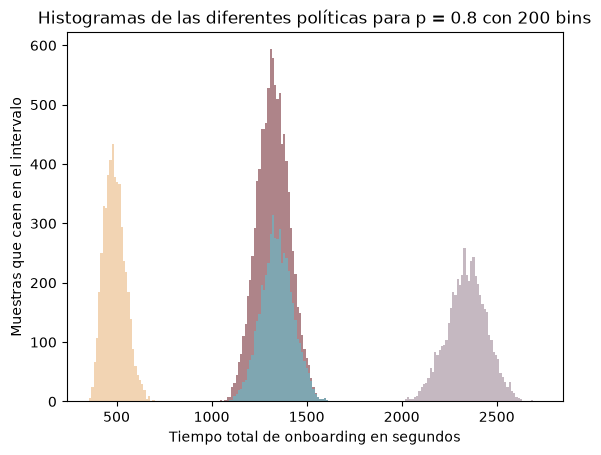

In [ ]:
n_bins = 200
data_btf = r.tiempos('btf')
data_rand = r.tiempos('rand')
data_wilma = r.tiempos('wilma')
data_stfn = r.tiempos('stfn')
colores = [(140/255, 114/255, 132/255, 0.5),(0, 78/255, 100/255, 0.5),(94/255, 11/255, 21/255, 0.5),(230/255, 170/255, 104/255, 0.5)]

plt.hist(x=[data_btf,data_rand,data_wilma,data_stfn], bins=n_bins, stacked=True, color=colores)
plt.title("Histogramas de las diferentes políticas para p = 0.8 con 200 bins")
plt.xlabel("Tiempo total de onboarding en segundos")
plt.ylabel("Muestras que caen en el intervalo")

plt.show()

La Steffen pareciera ser ligeramente asimétrica. Se verifica la intuición visual a partir del *skewness* (coeficiente de asimetría).

In [ ]:
skew(r.politicas['stfn'].tiempos)

np.float64(0.38942267816432996)

Para estimar el error del desvío no sirve el estimador por convención, pues asume distribución normal. Se procede a estimar el error del desvío de forma empírica mediante técnicas de *bootstrap*. Una vez hecho eso, se obtienen los percentiles 2,5% y 97,5% de la muestra, obteniendo así el IC del 95% para el desvío.

In [ ]:
s_boot = np.zeros(5000)

for i in range(5000):
    muestra = random.choices(population=r.politicas['stfn'].tiempos, k=5000)
    s_boot[i] = np.std(muestra, ddof=1)

ic_desvio = (np.percentile(s_boot, 2.5), np.percentile(s_boot, 97.5))
print(ic_desvio)

(np.float64(54.445359403321646), np.float64(56.59785885599887))


## **Bonus: Formas de Heterogeneidad**

En un escenario real, la fila avanza al ritmo del pasajero más lento. En nuestro modelo base, las velocidades de todos los pasajeros son iguales, pero esto no es realista. 

Esta extensión en nuestro código introduce parámetros (condición demográfica e impacto del carry-on) que influyen en los tiempos individuales aleatorios en cada agente, consiguiendo simular situaciones más realistas.

Nuevas reglas de comportamiento en el agente:
* Impacto del equipaje (Carry-on): Avanzar por el pasillo con un carry-on es más lento, sumando 1 segundo de demora por cada celda avanzada.
* Perfiles demográficos: Se asignan características especiales con probabilidades, sumando penalidades específicas a sus tiempos base:
    * Personas Mayores (con $15\%$ de probabilidad): Presentan dificultades de movilidad, tardando más en caminar ($+2$ seg) y en guardar su carry-on ($+10$ seg).
    * Embarazadas (con $4\%$ de probabilidad): El espacio reducido dificulta maniobrar en la zona de los asientos, por lo que tardan más en sentarse ($+5$ seg) o levantarse para dejar pasar a otro ($+4$ seg), además de una demora al guardar su carry-on ($+15$ seg).
    * Personas con Discapacidad (con $2\%$ de probabilidad): Representan el grupo con los tiempos más extensos, con fuertes penalidades para caminar ($+4$ seg), sentarse ($+8$ seg), levantarse ($+6$ seg) y guardar su carry-on ($+20$ seg).

## **Modelo heterogéneo**

In [5]:
model_bonus = PlaneModel(n=100, p=0.5, onboarding_method=METODO, agent_class=BonusAgent) # type: ignore

In [ ]:
results_bonus = run_simulations(n_simulations=N_SIMULACIONES, n_passengers=N_PASAJEROS, p_carryon=P_CARRYON, agent_class=BonusAgent) # type: ignore
save_results(results=results_bonus, n_passengers=N_PASAJEROS, p_carryon=P_CARRYON, etiqueta='bonus')

In [ ]:
gif_bonus = run_and_show(N_PASAJEROS, 0.5, method='rand', agent_class=BonusAgent) # type: ignore
display(Image(gif_bonus))

## **Conclusión del modelo heterogéneo**

Al observar los resultados, notamos que el tiempo promedio aumentó considerablemente para todas las políticas. Además, la varianza es mayor, lo que refleja cómo la presencia de unos pocos pasajeros con limitaciones en movilidad (pesonas mayores, con discapacidad, embarazadas) genera fluctuaciones impredecibles en el tiempo total.

Mientras que en el modelo base las demoras estaban determinadas estrictamente por las restricciones físicas del pasillo y el orden de ingreso, en este escenario comprobamos que la demora de unos pocos pasajeros penaliza inmediatamente el avance de toda la fila. Si bien las políticas optimizadas (como el método de Steffen) siguen siendo las más veloces en promedio, su margen de ventaja se reduce significativamente frente a alternativas tradicionales con la introducción de agentes heterogéneos. Esto pone en evidencia como los modelos teóricos altamente eficientes son particularmente sensibles a la imprevisibilidad del comportamiento humano y a la heterogeneidad real de los pasajeros.